In [14]:
import nasdaqdatalink

In [47]:
import pandas as pd

In [48]:
nasdaqdatalink.ApiConfig.api_key = ''

In [49]:
import nasdaqdatalink

df = nasdaqdatalink.get_table(
    datatable_code='WIKI/PRICES', 
    ticker='TSLA', 
    paginate=True, 
    api_key='ZaPU7PgLxfo-zu-62UYW'
)


In [50]:
df.head()

,ticker,date,open,high,low,close,volume,ex-dividend,split_ratio,adj_open,adj_high,adj_low,adj_close,adj_volume
None,,,,,,,,,,,,,,
0,TSLA,2018-03-27,304.00,304.27,277.18,279.18,13696168.0,0.0,1.0,304.00,304.27,277.18,279.18,13696168.0
1,TSLA,2018-03-26,307.34,307.59,291.36,304.18,8324639.0,0.0,1.0,307.34,307.59,291.36,304.18,8324639.0
2,TSLA,2018-03-23,311.25,311.61,300.45,301.54,6600538.0,0.0,1.0,311.25,311.61,300.45,301.54,6600538.0
3,TSLA,2018-03-22,313.89,318.82,308.18,309.10,4914307.0,0.0,1.0,313.89,318.82,308.18,309.10,4914307.0
4,TSLA,2018-03-21,310.25,322.44,310.19,316.53,5927881.0,0.0,1.0,310.25,322.44,310.19,316.53,5927881.0


In [51]:
df.shape

(1949, 14)

In [52]:
df.tail()

,ticker,date,open,high,low,close,volume,ex-dividend,split_ratio,adj_open,adj_high,adj_low,adj_close,adj_volume
None,,,,,,,,,,,,,,
1944,TSLA,2010-07-06,20.00,20.0000,15.83,16.11,6866900.0,0.0,1.0,20.00,20.0000,15.83,16.11,6866900.0
1945,TSLA,2010-07-02,23.00,23.1000,18.71,19.20,5139800.0,0.0,1.0,23.00,23.1000,18.71,19.20,5139800.0
1946,TSLA,2010-07-01,25.00,25.9200,20.27,21.96,8218800.0,0.0,1.0,25.00,25.9200,20.27,21.96,8218800.0
1947,TSLA,2010-06-30,25.79,30.4192,23.30,23.83,17187100.0,0.0,1.0,25.79,30.4192,23.30,23.83,17187100.0
1948,TSLA,2010-06-29,19.00,25.0000,17.54,23.89,18766300.0,0.0,1.0,19.00,25.0000,17.54,23.89,18766300.0


In [53]:
%matplotlib inline
import matplotlib.pyplot as plt

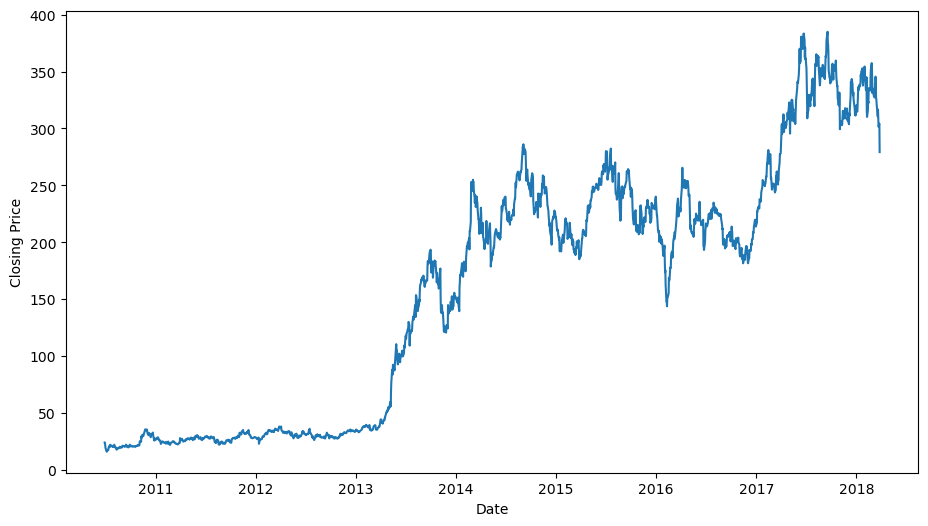

In [61]:
# 1. Ensure your date column is treated as datetime by Pandas
df['date'] = pd.to_datetime(df['date'])

# 2. Plot using standard Matplotlib instead of df.plot()
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(df['date'], df['close']) # Change 'close' to your preferred Y-axis column

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

In [152]:
prices = df['adj_close']
prices = prices.sort_index()
y_values = prices

In [191]:
volumes = df['adj_volume']
x_values = volumes

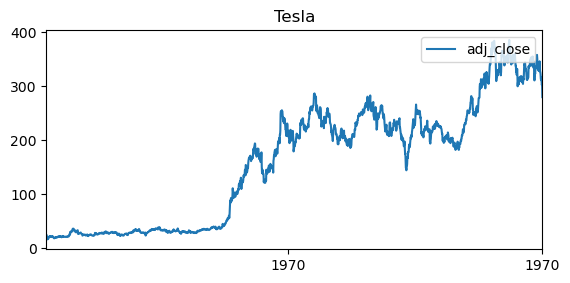

In [199]:
top = plt.subplot2grid((10,3), (0,0), rowspan=6, colspan=8)
prices.index = pd.to_datetime(prices.index)
top.plot(prices.index, prices, label='adj_close')
plt.title("Tesla")
plt.legend(loc=1)

date_min = prices.index.min()
date_max = prices.index.max()
top.set_xlim(date_max, date_min) # my logic is since the min was plotting the higher price first, just plot the max first then min.

plt.show()

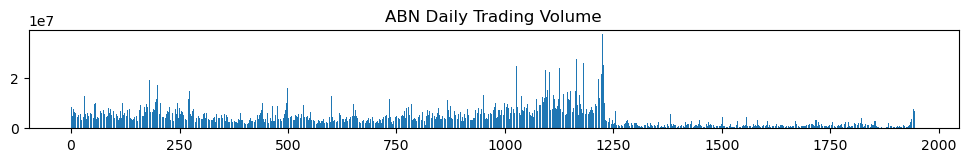

In [193]:
bottom = plt.subplot2grid((4, 4), (3,0), rowspan=1, colspan=4)
bottom.bar(volumes.index, volumes)
plt.title('ABN Daily Trading Volume')

plt.gcf().set_size_inches(12, 8)
plt.subplots_adjust(hspace=0.75)